## Conhecendo os dados

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [74]:
dados_idade_aposentadoria = pd.read_csv('/content/drive/MyDrive/Dados_Csv/dados_idade_aposentadoria.csv')

dados_altura = pd.read_csv('/content/drive/MyDrive/Dados_Csv/dados_alturas.csv')

dados_vida_lampada = pd.read_csv('/content/drive/MyDrive/Dados_Csv/dados_vida_lampada.csv')

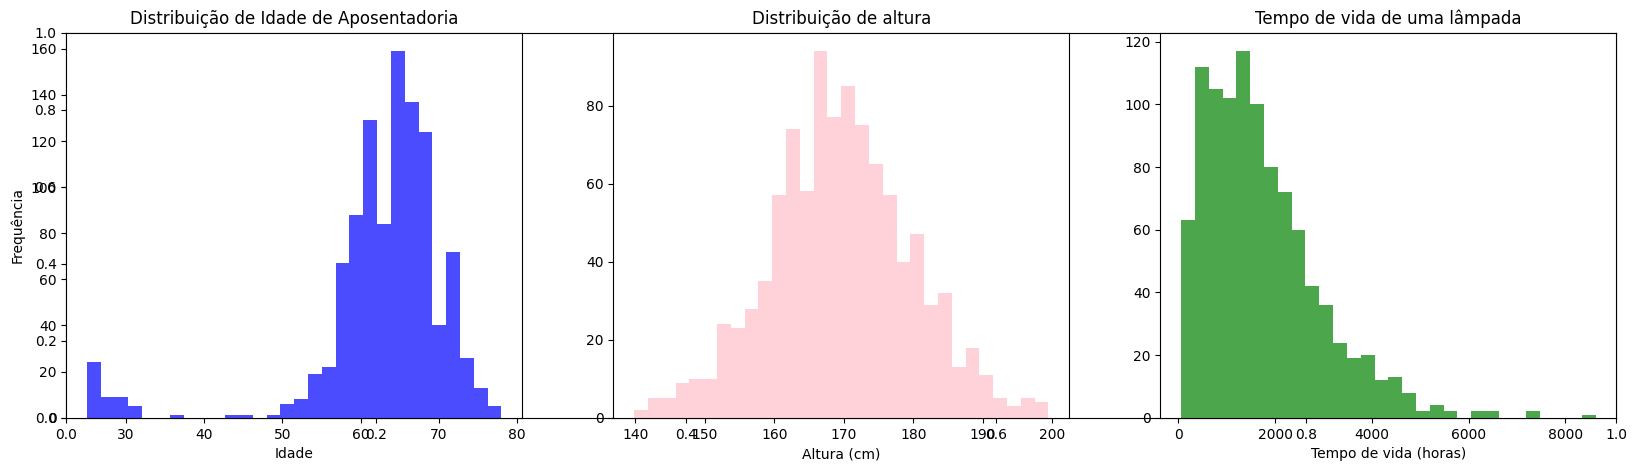

In [75]:
plt.subplots(figsize=(20,5))
plt.subplot(131)

plt.hist(dados_idade_aposentadoria, bins=30, alpha=0.7, color='blue')

plt.title('Distribuição de Idade de Aposentadoria')
plt.xlabel('Idade')
plt.ylabel('Frequência')

plt.subplot(132)

plt.hist(dados_altura, bins=30, alpha=0.7, color='pink')

plt.title('Distribuição de altura')
plt.xlabel('Altura (cm)')
plt.ylabel('')

plt.subplot(133)

plt.hist(dados_vida_lampada, bins=30, alpha=0.7, color='green')

plt.title('Tempo de vida de uma lâmpada')
plt.xlabel('Tempo de vida (horas)')
plt.ylabel('')

plt.show()

### Reamostragens

In [76]:
n = 100 # tamanho da amostra
qtd = 1000 # quantidades de amostras

def reamostragem_medias(dados, coluna, n, qtd):
  medias = [dados[coluna].sample(n, replace=True).mean() for _ in range(qtd)]
  return medias

In [77]:
media_idade = reamostragem_medias(dados_idade_aposentadoria, 'idade', n, qtd)
media_duracao = reamostragem_medias(dados_vida_lampada, 'duracao', n, qtd)
media_altura = reamostragem_medias(dados_altura, 'alturas', n, qtd)

### População vs Amostra

Vamos comparar agora a distribuição original com a distribuição das amostras, comparando a média das distribuições originais e com a distribuições médias das médias amostrais

In [78]:
print('------ Médias populacionais ------')

print(f"idade: {dados_idade_aposentadoria['idade'].mean()}")
print(f"Altura: {dados_altura['alturas'].mean()}")
print(f"Duração: {dados_vida_lampada['duracao'].mean()}")

------ Médias populacionais ------
idade: 62.70857142857143
Altura: 169.52022
Duração: 1731.8036029420002


In [79]:
def Media(lista):
  return sum(lista)/len(lista)

print('------ Médias amostrais ------')

print(f"idade: {Media(media_idade)}")
print(f"Altura: {Media(media_altura)}")
print(f"Duração: {Media(media_duracao)}")

------ Médias amostrais ------
idade: 62.710000000000015
Altura: 169.51621129999992
Duração: 1737.5393988550295


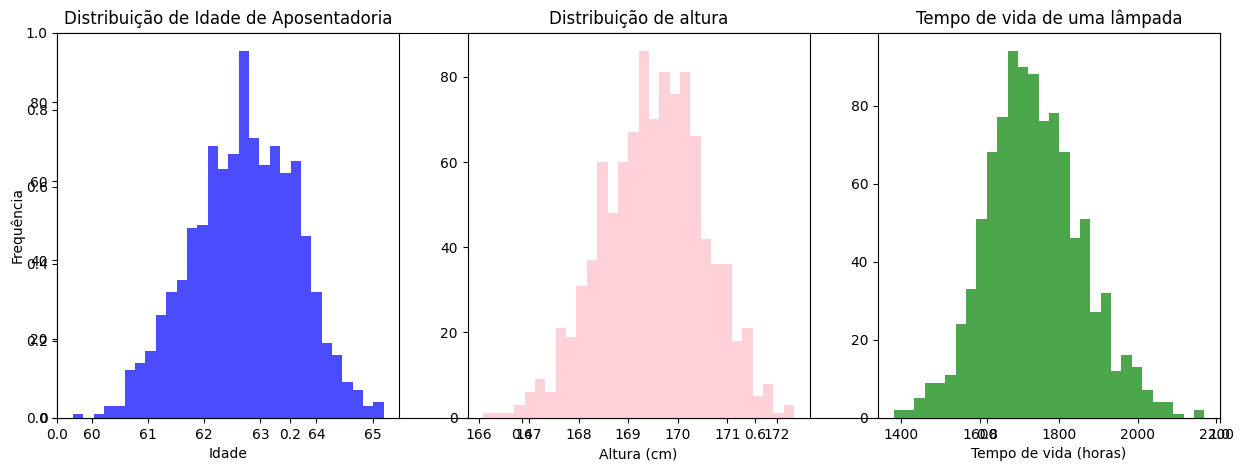

In [80]:
plt.subplots(figsize=(15,5))
plt.subplot(131)

plt.hist(media_idade, bins=30, alpha=0.7, color='blue')

plt.title('Distribuição de Idade de Aposentadoria')
plt.xlabel('Idade')
plt.ylabel('Frequência')

plt.subplot(132)

plt.hist(media_altura, bins=30, alpha=0.7, color='pink')

plt.title('Distribuição de altura')
plt.xlabel('Altura (cm)')
plt.ylabel('')

plt.subplot(133)

plt.hist(media_duracao, bins=30, alpha=0.7, color='green')

plt.title('Tempo de vida de uma lâmpada')
plt.xlabel('Tempo de vida (horas)')
plt.ylabel('')

plt.show()

## Caso 1

O primeiro caso é um controle de qualidade. A empresa nos disse que foi feita uma nova verificação nas lâmpadas e que a média de duração observada foi de 1.200 horas. Eles querem entender, será que a média mudou

In [81]:
# Media da nova amostra
media_nova_amostra = 1200

In [82]:
# Média original
dados_vida_lampada['duracao'].mean()

np.float64(1731.8036029420002)

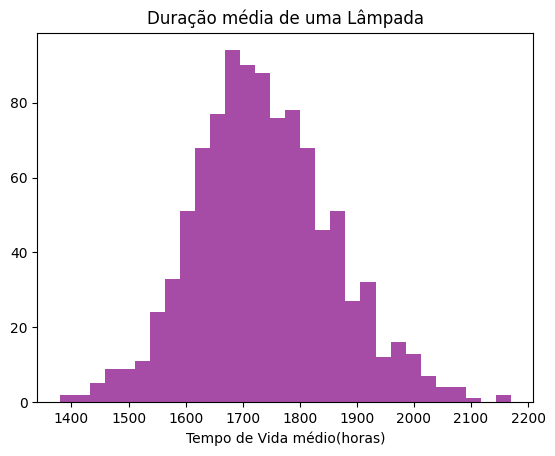

In [83]:
# Quão distante essa média está do comportamento?

plt.hist(media_duracao, bins=30, alpha=0.7, color='purple')
plt.title('Duração média de uma Lâmpada')
plt.xlabel('Tempo de Vida médio(horas)')
plt.annotate('.', xy=(media_nova_amostra, 0), xytext=(media_nova_amostra, 100), fontsize=8,
            arrowprops=dict(facecolor='green'))
plt.show()

### Distribuição Normal

Na distribuição normal, as médias amostrais geralmente se aproximam da média verdadeira. No entanto, a media pode variar entre amostras. O conceito de erro padrão ajuda a entender essa variação se a necessidade de um gráfico

In [84]:
duracao_amostras = pd.DataFrame({'medias duracao': media_duracao})
duracao_amostras

,medias duracao
0,1612.588978
1,1771.581036
2,1551.924451
3,1671.709880
4,1643.384248
...,...
995,1984.108417
996,1846.897939
997,1715.757363
998,1752.866270


In [85]:
media_das_medias = duracao_amostras['medias duracao'].mean()
EP = duracao_amostras['medias duracao'].std()
DS = dados_vida_lampada['duracao'].std()

print('----- Medidas Amostrais -----')
print(f'Média: {media_das_medias}')
print(f'EP: {EP}')

----- Medidas Amostrais -----
Média: 1737.53939885503
EP: 121.09182835932513


In [86]:
# Quantos erros?
media_das_medias - 3*EP

np.float64(1374.2639137770545)

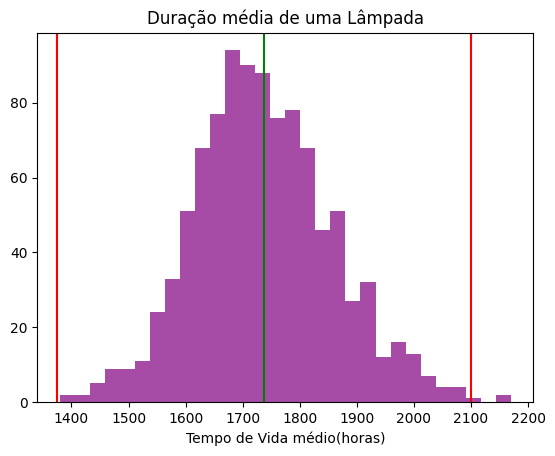

In [87]:
plt.hist(media_duracao, bins=30, alpha=0.7, color='purple')
plt.title('Duração média de uma Lâmpada')
plt.xlabel('Tempo de Vida médio(horas)')
plt.axvline(media_das_medias, color='green')
plt.axvline(media_das_medias + 3*EP, color='red')
plt.axvline(media_das_medias - 3*EP, color='red')
plt.annotate('.', xy=(media_nova_amostra, 0), xytext=(media_nova_amostra, 100), fontsize=8,
            arrowprops=dict(facecolor='green'))
plt.show()

In [88]:
# quanto está no intervalo de +ou- dois desvios

qnt_obs = duracao_amostras[duracao_amostras['medias duracao'].between(media_das_medias - 2*EP, media_das_medias + 2*EP)]

In [89]:
qnt_obs_2 = duracao_amostras[duracao_amostras['medias duracao'].between(media_das_medias - 3*EP, media_das_medias + 3*EP)]

In [90]:
# quanto isso representa?

qnt_obs.count()/duracao_amostras.count()

,0
medias duracao,0.942


In [91]:
# quanto isso representa?

qnt_obs_2.count()/duracao_amostras.count()

,0
medias duracao,0.997


## Caso 1 - Intervalo de Qualidade

Uma alternativa para otimizar todo o processo é criar uma margem de erro para a verdadeira média que acreditamos da duração das lâmpadas. Sabemos que a indústria leva em consideração que as lâmpadas duram 1.732 horas. Podemos trazer uma margem de erro para essa média.

In [92]:
from scipy import stats

In [93]:
# levar em consideração essa amostra
dados_vida_lampada

# nivel de confiança
confianca = 0.95

In [94]:
# informações para o intervalo de confiança

media = dados_vida_lampada['duracao'].mean()
desvio_padrao = dados_vida_lampada['duracao'].std()
n = len(dados_vida_lampada)

In [95]:
# Calculando intervalo de confiança

intervalo_confianca = stats.norm.interval(confianca,
                                          loc = media,
                                          scale = desvio_padrao/np.sqrt(n))

In [96]:
print(f"IC (95%): {intervalo_confianca}")

IC (95%): (np.float64(1658.3741665835485), np.float64(1805.233039300452))


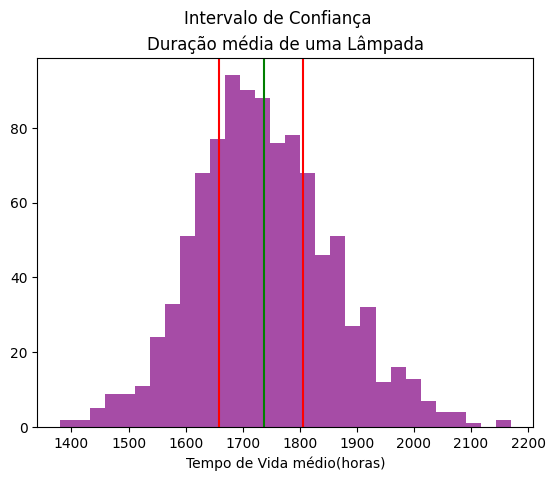

In [97]:
plt.hist(media_duracao, bins=30, alpha=0.7, color='purple')
plt.title('Duração média de uma Lâmpada')
plt.suptitle('Intervalo de Confiança')
plt.xlabel('Tempo de Vida médio(horas)')
plt.axvline(media_das_medias, color='green')
plt.axvline(intervalo_confianca[1], color='red')
plt.axvline(intervalo_confianca[0], color='red')
plt.annotate('.', xy=(media_nova_amostra, 0), xytext=(media_nova_amostra, 100), fontsize=8,
            arrowprops=dict(facecolor='green'))
plt.show()

In [98]:
intervalo_confianca_80 = stats.norm.interval(0.80,
                                          loc = media,
                                          scale = desvio_padrao/np.sqrt(n))
intervalo_confianca_80

(np.float64(1683.7906752226602), np.float64(1779.8165306613403))

## Caso 3 - Estabelecer a duração

Desta vez, temos um terceiro caso, no qual vamos estabelecer a duração de novas lâmpadas. Neste caso, são outros tipos de lâmpadas. Queremos entender se a duração média das lâmpadas de Natal, também fabricadas por esta indústria, é igual a ou diferente de 1.570 horas

*Suposição: "A duração média de todas as lâmpadas é igual a 1.570 horas".*

*Contraponto: "A duração média de todas as lâmpadas não é igual a 1.570 horas".*

### Formulando a hipótese

In [99]:
hipotese = 1570

### Estabelecendo a regra de decisão

Podemos olhar para essa hipótese de 1.570 horas e estabelecer uma margem de erro. Esse procedimento é o estabelecimento de um intervalo de confiança

In [100]:
lampadas_natalinas = pd.read_csv('/content/drive/MyDrive/Dados_Csv/experimento_lampadas_natalinas.csv')

In [101]:
# media amostral
media_amostra = lampadas_natalinas['duracao'].mean()
media_amostra

np.float64(1529.5081310675512)

In [102]:
confianca_1 = 0.95
desvio_padrao_populacional = 105
n = len(lampadas_natalinas['duracao'])
erro_padrao = desvio_padrao_populacional / np.sqrt(n)

In [103]:
# Calculando o Intervalo de Confiança
intervalo = stats.norm.interval(confianca_1,
                                loc = 1570,
                                scale = erro_padrao)
print(f'IC (95%):{intervalo}')

IC (95%):(np.float64(1549.4203781623294), np.float64(1590.5796218376706))


### intensidade de rejeitar a hipótese

Suponhamos que estamos no cenário errado, o cenário em que H₀ é verdadeira, ou seja, as lâmpadas estão durando 1.570 horas, em média.

*Qual a probabilidade de observarmos aquela média amostral que calculamos?*

**Aplicando o Teste Z**

In [104]:
# importando o teste Z do statsmodels

from statsmodels.stats.weightstats import ztest

In [105]:
#  executando o teste Z

estats, p_valor = ztest(x1=lampadas_natalinas['duracao'], value=1570, alternative='two-sided')

In [106]:
# media amostral
lampadas_natalinas['duracao'].mean()

np.float64(1529.5081310675512)

In [107]:
# exibe resultados
print(f"{p_valor:.10e}") # Se a média verdadeira fosse mesmo 1570, seria extremamente improvável observar uma amostra com a média que você obteve.

0.0000000000e+00


In [108]:
# verifica a hipótese nula com base no valor-p

if p_valor < 0.05:
    conclusao = "Rejeitar a hipótese nula"
else:
    conclusao = "Não rejeita a hipótese nula"

print("Conclusão:", conclusao)

Conclusão: Rejeitar a hipótese nula


In [109]:
estats

np.float64(-45.732770207263556)

## Caso 4: nível de serviço (SLA)

O tempo médio de resposta do suporte técnico oferecido é menor que 30 minutos, como prometido no acordo de nível de serviço?

*Suposição: "o tempo médio do suporte é igual a 30 minutos."*

*Contraponto: "o tempo médio do suporte é menor que 30 minutos"*

In [110]:
# Tempo de resposta em minutos para 25 solicitações de suporte
tempo_resposta = [28, 32, 29, 31, 30, 33, 28, 30, 31, 29,
                  30, 32, 29, 31, 30, 33, 28, 30, 31, 29,
                  30, 32, 24, 29, 30]

**Aplicando o teste T**

In [111]:
#média coletada do tempo
np.mean(tempo_resposta)

np.float64(29.96)

In [112]:
# importando ttets_1samp
from scipy.stats import ttest_1samp

In [113]:
# Realiza o teste t unilateral para a amostra
estats, p_valor = ttest_1samp(tempo_resposta, 30, alternative='less')

In [114]:
# Exibe resultados
print(p_valor)

0.4585970095667924


## Caso 5: Vendas vs Anúncio

### Amostras Independentes

In [115]:
vendas_com_propaganda = [329.80, 291.70, 338.86, 391.38, 285.95, 285.95, 394.75, 346.05, 271.83, 332.55, 272.19, 272.06, 314.52, 185.20, 196.50, 266.26, 239.23, 318.85, 245.52, 215.26, 387.94, 286.45, 304.05, 214.52, 267.34, 306.66, 230.94, 322.54, 263.96, 282.50, 263.90, 411.14, 299.19, 236.54, 349.35, 226.75, 312.53, 182.42, 220.31, 311.81, 344.31, 310.28, 293.66, 281.93, 211.29, 256.81, 272.36, 363.43, 320.62, 194.22]

In [116]:
vendas_sem_propaganda = [304.44, 261.89, 244.38, 321.70, 346.86, 348.08, 234.65, 266.45, 304.88, 343.53, 256.25, 273.86, 218.62, 213.23, 333.75, 366.37, 280.68, 345.21, 306.70, 246.29, 306.68, 377.28, 282.85, 378.88, 127.82, 334.31, 290.22, 267.06, 290.51, 165.74, 271.82, 306.43, 373.67, 253.90, 236.49, 254.89, 339.92, 304.73, 253.21, 315.80, 292.80, 343.12, 242.88, 265.34, 261.47, 197.19, 302.77, 300.66, 285.31, 270.92]

In [117]:
# média com propaganda
print(np.mean(vendas_com_propaganda))
# média sem propaganda
print(np.mean(vendas_sem_propaganda))

286.4832
286.2498


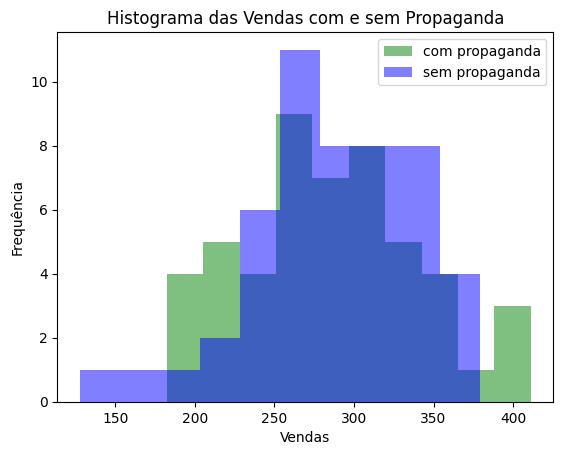

In [118]:
# Criar histogramas
plt.hist(vendas_com_propaganda, color = "green", alpha = 0.5, label = "com propaganda")
plt.hist(vendas_sem_propaganda, color = "blue", alpha = 0.5, label = "sem propaganda")

# Adicionar rótulos e título
plt.xlabel('Vendas')
plt.ylabel('Frequência')
plt.title('Histograma das Vendas com e sem Propaganda')
plt.legend()
plt.show()

Hipóteses desse teste de amostras independentes:

*H0: média sem = média com*

*H1: média sem < média com*

In [119]:
# teste t para amostras independentes (ttest_ind)
from scipy.stats import ttest_ind

In [120]:
estast, p_valor = ttest_ind(vendas_com_propaganda, vendas_sem_propaganda, alternative='greater')

In [121]:
print(p_valor)

0.49145652153110797


In [122]:
alpha = 0.05
if p_valor < alpha:
    print("Rejeitar a hipótese nula: Há evidências de que a propaganda tem um efeito positivo nas vendas.")
else:
    print("Não rejeita hipótese nula: Não há evidências suficientes para afirmar um efeito positivo nas vendas devido à propaganda.")

Não rejeita hipótese nula: Não há evidências suficientes para afirmar um efeito positivo nas vendas devido à propaganda.


## Caso 6: Notas antes de Depois

Precisamos testar se o treinamento para a equipe de atendimento promoveu uma diferença nas avaliações.

### Amostras Dependentes (Pareadas)

In [123]:
antes_do_treinamento =[78, 65, 75, 80, 85, 88, 79, 81, 76, 84]
apos_o_treinamento = [85, 70, 75, 87, 90, 92, 84, 82, 76, 91]

In [124]:
resultado_subtracao = [b - a for a, b in zip(antes_do_treinamento, apos_o_treinamento)]

In [125]:
resultado_subtracao

[7, 5, 0, 7, 5, 4, 5, 1, 0, 7]

Hipóteses desse teste de amostras pareadas:

*H0 : µd = 0*

*H1 : µd > 0*

µd é média das diferenças dos pares.

In [126]:
# importando o teste pareado ttest_rel
from scipy.stats import ttest_rel

In [127]:
estats, p_valor = ttest_rel(apos_o_treinamento, antes_do_treinamento, alternative='greater')

In [128]:
p_valor

np.float64(0.000627744161772394)

## O Caso 7: Treino A contra Treino B

A academia vende dois planos de treino, o A e o B, e quer entender se há diferença significativa nos ganhos de desempenho de força entre quem pratica os dois tipos.

In [129]:
# Dados de desempenho dos dois grupos
treino_a = [5, 3, 8, 4, 6]
treino_b = [4, 2, 7, 5, 3]

In [130]:
from scipy.stats import mannwhitneyu

*H0 : As distribuições das duas populações são iguais*

*H1 : As distribuições das duas populações são diferentes*

In [131]:
estats, p_valor = mannwhitneyu(treino_a, treino_b, alternative='two-sided')

In [132]:
p_valor

np.float64(0.4605966187047713)

## Caso 8: Layout antes e depois

A hipótese que testaremos é:

*Não há uma diferença significativa nas preferências antes e depois da mudança da disposição dos equipamentos na academia.*

In [133]:
# Preferências dos consumidores antes e depois da mudança no layout
preferencias_antes = [4, 2, 5, 2, 5, 6, 7, 8, 9, 10 ]
preferencias_depois = [8, 5, 3, 5, 8, 9, 9, 9, 10, 9]

In [134]:
#diferenças de percepção
resultado_subtracao = [b - a for a, b in zip(preferencias_antes,preferencias_depois)]

In [135]:
resultado_subtracao

[4, 3, -2, 3, 3, 3, 2, 1, 1, -1]

In [136]:
np.mean(resultado_subtracao)

np.float64(1.7)

In [137]:
np.median(resultado_subtracao)

np.float64(2.5)

*H0 : A mediana das diferenças entre os pares é zero*

*H1 : A mediana das diferenças entre os pares não é zero*

In [138]:
# importando teste de wilcoxon
from scipy.stats import wilcoxon

In [139]:
estast, p_valor = wilcoxon(preferencias_depois, preferencias_antes, alternative='greater')

In [140]:
p_valor

np.float64(0.015625)

In [141]:
nivel_significancia=0.05

if p_valor < nivel_significancia:
    conclusao = "Rejeitar a hipótese nula"
else:
    conclusao = "Não rejeita a hipótese nula"
conclusao

'Rejeitar a hipótese nula'